In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/creditcardfraud/creditcard.csv


In [146]:
#Libraries
import pandas  as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

import imblearn
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline


from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold

#Models [LogisticRegression, SVM, SGD, GaussianNB, ElasticNet, Tree, RandomForrestClassifier]
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import ElasticNet
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

#Metrics
from sklearn.metrics import confusion_matrix

In [9]:
df = pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


0    284315
1       492
Name: Class, dtype: int64

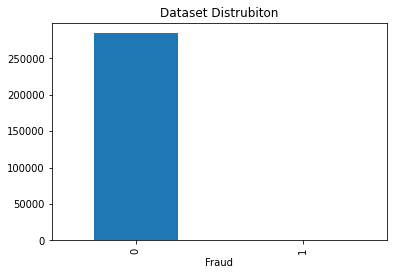

In [10]:
pd.value_counts(df['Class']).plot.bar()
plt.title('Dataset Distrubiton')
plt.xlabel('Fraud')
df['Class'].value_counts()

In [11]:
df.shape

(284807, 31)

In [12]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [15]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [16]:
df.describe().round(6)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,...,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000
mean,94813.859575,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,-0.000000,...,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,88.349619,0.001727
std,47488.145955,1.958696,1.651309,1.516255,1.415869,1.380247,1.332271,1.237094,1.194353,1.098632,...,0.734524,0.725702,0.624460,0.605647,0.521278,0.482227,0.403632,0.330083,250.120109,0.041527
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54201.500000,-0.920373,-0.598550,-0.890365,-0.848640,-0.691597,-0.768296,-0.554076,-0.208630,-0.643098,...,-0.228395,-0.542350,-0.161846,-0.354586,-0.317145,-0.326984,-0.070840,-0.052960,5.600000,0.000000
50%,84692.000000,0.018109,0.065486,0.179846,-0.019847,-0.054336,-0.274187,0.040103,0.022358,-0.051429,...,-0.029450,0.006782,-0.011193,0.040976,0.016594,-0.052139,0.001342,0.011244,22.000000,0.000000
75%,139320.500000,1.315642,0.803724,1.027196,0.743341,0.611926,0.398565,0.570436,0.327346,0.597139,...,0.186377,0.528554,0.147642,0.439527,0.350716,0.240952,0.091045,0.078280,77.165000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [17]:
df.corr().round(2)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.00,0.12,-0.01,-0.42,-0.11,0.17,-0.06,0.08,-0.04,-0.01,...,0.04,0.14,0.05,-0.02,-0.23,-0.04,-0.01,-0.01,-0.01,-0.01
V1,0.12,1.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,...,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.23,-0.10
V2,-0.01,0.00,1.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,...,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.53,0.09
V3,-0.42,-0.00,0.00,1.00,0.00,-0.00,0.00,0.00,-0.00,0.00,...,0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.21,-0.19
V4,-0.11,-0.00,-0.00,0.00,1.00,-0.00,-0.00,-0.00,0.00,0.00,...,-0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,0.10,0.13
V5,0.17,0.00,0.00,-0.00,-0.00,1.00,0.00,0.00,0.00,0.00,...,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.39,-0.09
V6,-0.06,-0.00,0.00,0.00,-0.00,0.00,1.00,0.00,-0.00,0.00,...,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.22,-0.04
V7,0.08,-0.00,0.00,0.00,-0.00,0.00,0.00,1.00,0.00,0.00,...,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.40,-0.19
V8,-0.04,-0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,1.00,0.00,...,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.10,0.02
V9,-0.01,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,...,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.04,-0.10


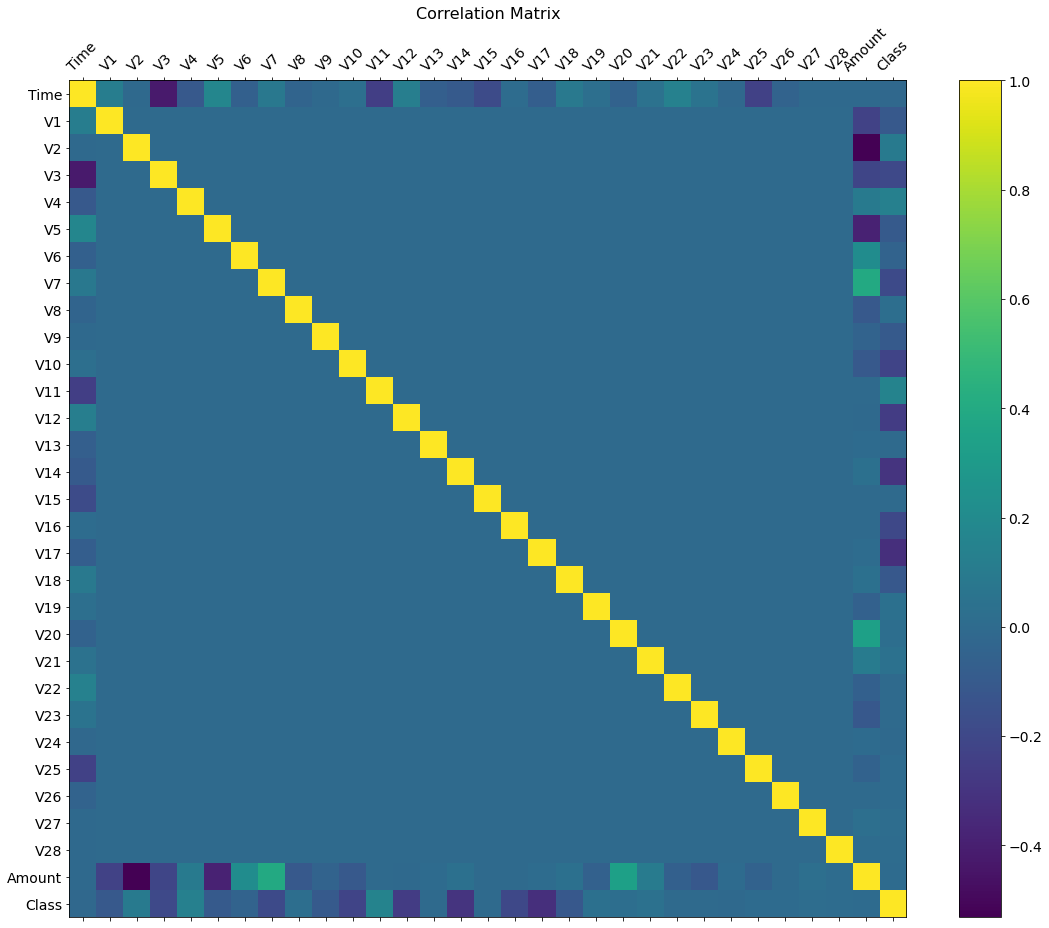

In [18]:
f = plt.figure(figsize=(19, 15))
plt.matshow(df.corr(), fignum=f.number)
plt.xticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=14, rotation=45)
plt.yticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16);

In [19]:
df_features = df.loc[:, :'Amount']

In [20]:
df_features.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [21]:
df_target = df.pop('Class')

In [26]:
df_target

0         0
1         0
2         0
3         0
4         0
         ..
284802    0
284803    0
284804    0
284805    0
284806    0
Name: Class, Length: 284807, dtype: int64

# Evaluations

# Split the data into train and test: 67% Train 33% Test 

# Example train-test set.

In [110]:
X_train, X_test, y_train, y_test = train_test_split(df_features, df_target, test_size=0.33, random_state=10)

In [111]:
print("Number transactions X_train dataset: ", X_train.shape)
print("Number transactions y_train dataset: ", y_train.shape)
print("Number transactions X_test dataset: ", X_test.shape)
print("Number transactions y_test dataset: ", y_test.shape)

Number transactions X_train dataset:  (190820, 30)
Number transactions y_train dataset:  (190820,)
Number transactions X_test dataset:  (93987, 30)
Number transactions y_test dataset:  (93987,)


# Evaluation function

## Automatically calculate precision, accuracy, recall, f1 scores from calculated from confusion matrix.

In [127]:
def confusion_matrix_scorer(clf, testX, testy):
    y_pred = clf.predict(testX)
    cm = confusion_matrix(testy, y_pred)
    cm_dict = {'tn': cm[0, 0], 'fp': cm[0, 1], 'fn': cm[1, 0], 'tp': cm[1, 1]}
    true_pos = cm[1, 1]
    true_neg = cm[0, 0]
    false_pos = cm[0, 1]
    false_neg = cm[1, 0]
    prec = true_pos / (true_pos + false_pos)
    acc = (true_pos + true_neg ) / (true_pos+true_neg+false_pos+false_neg)
    f1 = 2* true_pos / (2*true_pos + false_pos + false_neg)
    recall = true_pos / (true_pos + false_neg) 
    print('Precision: ', prec, ' Accuracy: ', acc, ' Recall: ', recall, ' F1 :', f1)
    print('Confusion Matrix: ', cm_dict)
    return prec, acc, f1, recall


## Model evaluator takes model, fits the dataset then and calculates

In [129]:
def model_evaluator(model, train, test):
    model_5_iter_avg = [0,0,0,0]
    for i in range(5):
        X_train, X_test, y_train, y_test = train_test_split(df_features, df_target, test_size=0.33)
        model.fit(X_train,y_train)
        result = confusion_matrix_scorer(model, X_test,y_test)
        model_5_iter_avg[0] += result[0]
        model_5_iter_avg[1] += result[1]
        model_5_iter_avg[2] += result[2]
        model_5_iter_avg[3] += result[3]
    avg_score = [x/5 for x in model_5_iter_avg]
    print("Precision: ", avg_score[0], " Accuracy: ", avg_score[1], " Recall: ", avg_score[2], " F1: ", avg_score[3])
    return(avg_score)

# Models

In [147]:
logreg = LogisticRegression(max_iter = 200)
sgd_clf = SGDClassifier(loss="hinge", penalty="l2", max_iter=30)
clf_svm = svm.SVC()
clf_gnb = GaussianNB()
clf_tree = tree.DecisionTreeClassifier()
clf_random_forrest = RandomForestClassifier(n_estimators=10)

In [148]:
print("<--------------------Logreg------------------>")
model_evaluator(logreg, df_features, df_target)
print("<--------------------Logreg------------------>")

<--------------------Logreg------------------>


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


Precision:  0.6986301369863014  Accuracy:  0.9990105014523285  Recall:  0.6754966887417219  F1 : 0.6868686868686869
Confusion Matrix:  {'tn': 93792, 'fp': 44, 'fn': 49, 'tp': 102}


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


Precision:  0.7391304347826086  Accuracy:  0.9989892219136689  Recall:  0.6918604651162791  F1 : 0.7147147147147147
Confusion Matrix:  {'tn': 93773, 'fp': 42, 'fn': 53, 'tp': 119}
Precision:  0.8220338983050848  Accuracy:  0.9991913775309351  Recall:  0.6381578947368421  F1 : 0.7185185185185186
Confusion Matrix:  {'tn': 93814, 'fp': 21, 'fn': 55, 'tp': 97}


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


Precision:  0.7982456140350878  Accuracy:  0.9990211412216583  Recall:  0.56875  F1 : 0.6642335766423357
Confusion Matrix:  {'tn': 93804, 'fp': 23, 'fn': 69, 'tp': 91}
Precision:  0.6711409395973155  Accuracy:  0.9989998616829987  Recall:  0.6896551724137931  F1 : 0.6802721088435374
Confusion Matrix:  {'tn': 93793, 'fp': 49, 'fn': 45, 'tp': 100}
Precision:  0.7458362047412795  Accuracy:  0.999042420760318  Recall:  0.6929215211175587  F1:  0.6527840442017273
<--------------------Logreg------------------>


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


In [149]:
print("<--------------------Schotastic Gradient Descent ------------------>")
model_evaluator(sgd_clf, df_features, df_target)
print("<--------------------Schotastic Gradient Descent ------------------>")

<--------------------Schotastic Gradient Descent ------------------>


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:700: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning,


Precision:  0.0  Accuracy:  0.9982018789832636  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93818, 'fp': 4, 'fn': 165, 'tp': 0}


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:700: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning,


Precision:  0.0  Accuracy:  0.9982231585219232  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93820, 'fp': 7, 'fn': 160, 'tp': 0}


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:700: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning,


Precision:  0.0  Accuracy:  0.9984359539085192  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93840, 'fp': 4, 'fn': 143, 'tp': 0}


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:700: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning,


Precision:  0.0  Accuracy:  0.9982976369072318  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93827, 'fp': 4, 'fn': 156, 'tp': 0}
Precision:  nan  Accuracy:  0.9982657175992424  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93824, 'fp': 0, 'fn': 163, 'tp': 0}
Precision:  nan  Accuracy:  0.998284869184036  Recall:  0.0  F1:  0.0
<--------------------Schotastic Gradient Descent ------------------>


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:700: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning,
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == "__main__":


In [150]:
print("<--------------------Support Vector Machine------------------>")
model_evaluator(clf_svm, df_features, df_target)
print("<--------------------Support Vector Machine------------------>")

<--------------------Support Vector Machine------------------>


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == "__main__":


Precision:  nan  Accuracy:  0.9981912392139338  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93817, 'fp': 0, 'fn': 170, 'tp': 0}


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == "__main__":


Precision:  nan  Accuracy:  0.9982018789832636  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93818, 'fp': 0, 'fn': 169, 'tp': 0}


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == "__main__":


Precision:  nan  Accuracy:  0.998021002904657  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93801, 'fp': 0, 'fn': 186, 'tp': 0}


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == "__main__":


Precision:  nan  Accuracy:  0.9982444380605828  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93822, 'fp': 0, 'fn': 165, 'tp': 0}
Precision:  nan  Accuracy:  0.998233798291253  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93821, 'fp': 0, 'fn': 166, 'tp': 0}
Precision:  nan  Accuracy:  0.998178471490738  Recall:  0.0  F1:  0.0
<--------------------Support Vector Machine------------------>


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == "__main__":


In [151]:
print("<--------------------Gaussian Naive Bayes------------------>")
model_evaluator(clf_gnb, df_features, df_target)
print("<--------------------Gaussian Naive Bayes------------------>")

<--------------------Gaussian Naive Bayes------------------>
Precision:  0.14464534075104313  Accuracy:  0.9927436773170758  Recall:  0.6081871345029239  F1 : 0.23370786516853934
Confusion Matrix:  {'tn': 93201, 'fp': 615, 'fn': 67, 'tp': 104}
Precision:  0.13916786226685796  Accuracy:  0.9930415908583102  Recall:  0.6423841059602649  F1 : 0.22877358490566038
Confusion Matrix:  {'tn': 93236, 'fp': 600, 'fn': 54, 'tp': 97}
Precision:  0.14263565891472868  Accuracy:  0.9935416600168109  Recall:  0.6301369863013698  F1 : 0.23261694058154236
Confusion Matrix:  {'tn': 93288, 'fp': 553, 'fn': 54, 'tp': 92}
Precision:  0.13561643835616438  Accuracy:  0.992786236394395  Recall:  0.678082191780822  F1 : 0.22602739726027396
Confusion Matrix:  {'tn': 93210, 'fp': 631, 'fn': 47, 'tp': 99}
Precision:  0.16973125884016974  Accuracy:  0.9931692680902678  Recall:  0.6857142857142857  F1 : 0.272108843537415
Confusion Matrix:  {'tn': 93225, 'fp': 587, 'fn': 55, 'tp': 120}
Precision:  0.14635931182579276

In [152]:
print("<--------------------Decision Tree Classifier------------------>")
model_evaluator(clf_tree, df_features, df_target)
print("<--------------------Decision Tree Classifier------------------>")

<--------------------Decision Tree Classifier------------------>
Precision:  0.7988505747126436  Accuracy:  0.9992977752242331  Recall:  0.8176470588235294  F1 : 0.8081395348837209
Confusion Matrix:  {'tn': 93782, 'fp': 35, 'fn': 31, 'tp': 139}
Precision:  0.7294117647058823  Accuracy:  0.9988934639897007  Recall:  0.6813186813186813  F1 : 0.7045454545454546
Confusion Matrix:  {'tn': 93759, 'fp': 46, 'fn': 58, 'tp': 124}
Precision:  0.6910112359550562  Accuracy:  0.9989573026056795  Recall:  0.7409638554216867  F1 : 0.7151162790697675
Confusion Matrix:  {'tn': 93766, 'fp': 55, 'fn': 43, 'tp': 123}
Precision:  0.7349397590361446  Accuracy:  0.9990317809909881  Recall:  0.7218934911242604  F1 : 0.7283582089552239
Confusion Matrix:  {'tn': 93774, 'fp': 44, 'fn': 47, 'tp': 122}
Precision:  0.7393939393939394  Accuracy:  0.9991381786842861  Recall:  0.7625  F1 : 0.7507692307692307
Confusion Matrix:  {'tn': 93784, 'fp': 43, 'fn': 38, 'tp': 122}
Precision:  0.7387214547607333  Accuracy:  0.99

In [153]:
print("<--------------------Random Forrest Classifier------------------>")
model_evaluator(clf_random_forrest, df_features, df_target)
print("<--------------------Random Forrest Classifier------------------>")

<--------------------Random Forrest Classifier------------------>
Precision:  0.917910447761194  Accuracy:  0.9994892910721696  Recall:  0.76875  F1 : 0.8367346938775511
Confusion Matrix:  {'tn': 93816, 'fp': 11, 'fn': 37, 'tp': 123}
Precision:  0.9310344827586207  Accuracy:  0.999574409226808  Recall:  0.7714285714285715  F1 : 0.84375
Confusion Matrix:  {'tn': 93839, 'fp': 8, 'fn': 32, 'tp': 108}
Precision:  0.968  Accuracy:  0.999574409226808  Recall:  0.7707006369426752  F1 : 0.8581560283687943
Confusion Matrix:  {'tn': 93826, 'fp': 4, 'fn': 36, 'tp': 121}
Precision:  0.9351851851851852  Accuracy:  0.9994573717641801  Recall:  0.696551724137931  F1 : 0.7984189723320159
Confusion Matrix:  {'tn': 93835, 'fp': 7, 'fn': 44, 'tp': 101}
Precision:  0.9609375  Accuracy:  0.9995318501494888  Recall:  0.7592592592592593  F1 : 0.8482758620689655
Confusion Matrix:  {'tn': 93820, 'fp': 5, 'fn': 39, 'tp': 123}
Precision:  0.9426135231409999  Accuracy:  0.9995254662878909  Recall:  0.837067111329

# Oversampling the data with SMOTE

In [159]:
sm = SMOTE(random_state = 42)
X_train_oversampled, y_train_oversampled = sm.fit_resample(df_features, df_target)
df_features_oversample = pd.DataFrame(X_train_oversampled, columns=df_features.columns)
df_target_oversample = pd.DataFrame(y_train_oversampled, columns=pd.DataFrame(df_target).columns)

In [162]:
df_features_oversample

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.000000,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.620000
1,0.000000,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.690000
2,1.000000,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.660000
3,1.000000,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.500000
4,2.000000,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.990000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568625,144838.659385,-6.379157,1.672637,-5.885670,2.068340,-0.668576,-3.336450,-4.995823,2.632847,-2.275158,...,-0.709398,0.641337,-0.249308,-2.311290,-0.159402,1.190079,-0.258067,0.777265,-0.728919,7.334751
568626,65965.011763,-2.479028,0.958932,-1.782249,1.541783,-1.191990,-0.466794,-1.957161,0.312580,-0.433956,...,-0.263193,0.351983,0.208869,-0.235986,-0.404446,0.220454,0.685263,-0.890346,0.598736,74.507571
568627,34592.129093,-1.799894,2.368957,-2.673997,1.705968,-1.355923,-1.121788,-2.057832,-1.677459,-0.659287,...,0.468282,1.473371,-0.581778,-0.013899,-0.144597,0.120315,0.242272,-0.121166,-0.534238,102.486823
568628,129683.002907,0.255234,2.432041,-5.388252,3.793925,-0.230814,-1.382725,-1.572929,0.748305,-1.600633,...,0.197287,0.316760,-0.036858,0.182968,0.190701,-0.339250,-0.272824,0.315507,-0.091005,58.346854


In [183]:
df_features_oversample.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,568630.000000,568630.000000,568630.000000,568630.000000,568630.000000,568630.000000,568630.000000,568630.000000,568630.000000,568630.000000,...,568630.000000,568630.000000,568630.000000,568630.000000,568630.000000,568630.000000,568630.000000,568630.000000,568630.000000,568630.000000
mean,87818.934720,-2.473468,1.915852,-3.642628,2.327472,-1.625158,-0.714689,-2.927150,0.265285,-1.330435,...,0.184993,0.399645,-0.009664,-0.002834,-0.055105,0.026087,0.027824,0.081257,0.041545,95.524613
std,48121.839247,5.446449,3.632325,6.145809,3.142557,4.127046,1.706042,5.708276,4.969988,2.224967,...,1.033327,2.864329,1.168768,1.014914,0.539759,0.612429,0.446920,0.951350,0.417802,220.351621
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-54.497720,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000
25%,46004.895144,-3.060335,-0.094872,-5.230748,-0.053983,-1.826666,-1.548754,-3.251343,-0.197940,-2.324595,...,-0.188007,-0.158189,-0.498755,-0.223012,-0.384585,-0.302902,-0.267081,-0.067497,-0.057070,3.339762
50%,80283.500000,-0.819901,1.020226,-1.550720,1.481414,-0.444632,-0.692929,-0.752219,0.168431,-0.809343,...,0.040140,0.161706,0.021607,-0.026558,-0.008043,0.044851,-0.006961,0.058331,0.036705,25.000000
75%,134730.750000,0.826010,2.892812,0.267757,4.339191,0.427730,0.023763,0.186328,0.852409,0.077581,...,0.436199,0.649646,0.526878,0.187852,0.339494,0.367149,0.308256,0.433484,0.213839,99.990000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,39.420904,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000


In [163]:
df_target_oversample

,Class
0,0
1,0
2,0
3,0
4,0
...,...
568625,1
568626,1
568627,1
568628,1


In [182]:
df_target_oversample.describe()

,Class
count,568630.0
mean,0.5
std,0.5
min,0.0
25%,0.0
50%,0.5
75%,1.0
max,1.0


# Oversampled Data
## We have same amount of fraud and non fraud activity transactions after oversample.

0    568630
1    568630
Name: Class, dtype: int64

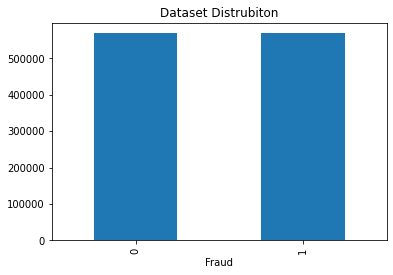

In [172]:
pd.value_counts(df_oversample['Class']).plot.bar()
plt.title('Dataset Distrubiton')
plt.xlabel('Fraud')
df_oversample['Class'].value_counts()

# Experiments with oversampled  data

In [173]:
print("<--------------------Decision Tree Classifier------------------>")
model_evaluator(clf_tree, df_features_oversample, df_target_oversample)
print("<--------------------Decision Tree Classifier------------------>")

<--------------------Decision Tree Classifier------------------>
Precision:  0.7745664739884393  Accuracy:  0.9991700979922755  Recall:  0.7745664739884393  F1 : 0.7745664739884393
Confusion Matrix:  {'tn': 93775, 'fp': 39, 'fn': 39, 'tp': 134}
Precision:  0.7305389221556886  Accuracy:  0.9991062593762967  Recall:  0.7577639751552795  F1 : 0.7439024390243902
Confusion Matrix:  {'tn': 93781, 'fp': 45, 'fn': 39, 'tp': 122}
Precision:  0.7650602409638554  Accuracy:  0.9991913775309351  Recall:  0.774390243902439  F1 : 0.7696969696969697
Confusion Matrix:  {'tn': 93784, 'fp': 39, 'fn': 37, 'tp': 127}
Precision:  0.8013698630136986  Accuracy:  0.9992020173002649  Recall:  0.7177914110429447  F1 : 0.7572815533980582
Confusion Matrix:  {'tn': 93795, 'fp': 29, 'fn': 46, 'tp': 117}
Precision:  0.7225806451612903  Accuracy:  0.9992232968389245  Recall:  0.7887323943661971  F1 : 0.7542087542087542
Confusion Matrix:  {'tn': 93802, 'fp': 43, 'fn': 30, 'tp': 112}
Precision:  0.7588232290565944  Accu

In [174]:
print("<--------------------Random Forrest Classifier------------------>")
model_evaluator(clf_random_forrest, df_features_oversample, df_target_oversample)
print("<--------------------Random Forrest Classifier------------------>")

<--------------------Random Forrest Classifier------------------>
Precision:  0.8881118881118881  Accuracy:  0.9994573717641801  Recall:  0.7839506172839507  F1 : 0.8327868852459016
Confusion Matrix:  {'tn': 93809, 'fp': 16, 'fn': 35, 'tp': 127}
Precision:  0.9482758620689655  Accuracy:  0.9994892910721696  Recall:  0.7236842105263158  F1 : 0.8208955223880597
Confusion Matrix:  {'tn': 93829, 'fp': 6, 'fn': 42, 'tp': 110}
Precision:  0.9083969465648855  Accuracy:  0.9995424899188186  Recall:  0.7933333333333333  F1 : 0.8469750889679716
Confusion Matrix:  {'tn': 93825, 'fp': 12, 'fn': 31, 'tp': 119}
Precision:  0.9552238805970149  Accuracy:  0.9995637694574782  Recall:  0.7852760736196319  F1 : 0.8619528619528619
Confusion Matrix:  {'tn': 93818, 'fp': 6, 'fn': 35, 'tp': 128}
Precision:  0.9558823529411765  Accuracy:  0.9994786513028397  Recall:  0.7514450867052023  F1 : 0.8414239482200647
Confusion Matrix:  {'tn': 93808, 'fp': 6, 'fn': 43, 'tp': 130}
Precision:  0.931178186056786  Accura

In [175]:
print("<--------------------Gaussian Naive Bayes------------------>")
model_evaluator(clf_gnb, df_features_oversample, df_target_oversample)
print("<--------------------Gaussian Naive Bayes------------------>")

<--------------------Gaussian Naive Bayes------------------>
Precision:  0.15083798882681565  Accuracy:  0.992892634087693  Recall:  0.6428571428571429  F1 : 0.24434389140271492
Confusion Matrix:  {'tn': 93211, 'fp': 608, 'fn': 60, 'tp': 108}
Precision:  0.15129682997118155  Accuracy:  0.9930841499356294  Recall:  0.6325301204819277  F1 : 0.2441860465116279
Confusion Matrix:  {'tn': 93232, 'fp': 589, 'fn': 61, 'tp': 105}
Precision:  0.14482758620689656  Accuracy:  0.992786236394395  Recall:  0.6441717791411042  F1 : 0.23648648648648649
Confusion Matrix:  {'tn': 93204, 'fp': 620, 'fn': 58, 'tp': 105}
Precision:  0.1698389458272328  Accuracy:  0.9933075850915553  Recall:  0.651685393258427  F1 : 0.2694541231126597
Confusion Matrix:  {'tn': 93242, 'fp': 567, 'fn': 62, 'tp': 116}
Precision:  0.138442521631644  Accuracy:  0.9920095332333195  Recall:  0.6746987951807228  F1 : 0.22974358974358974
Confusion Matrix:  {'tn': 93124, 'fp': 697, 'fn': 54, 'tp': 112}
Precision:  0.15104877449275414 

In [176]:
print("<--------------------Support Vector Machine------------------>")
model_evaluator(clf_svm, df_features_oversample, df_target_oversample)
print("<--------------------Support Vector Machine------------------>")

<--------------------Support Vector Machine------------------>


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == "__main__":


Precision:  nan  Accuracy:  0.998286997137902  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93826, 'fp': 0, 'fn': 161, 'tp': 0}


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == "__main__":


Precision:  nan  Accuracy:  0.9983827550618702  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93835, 'fp': 0, 'fn': 152, 'tp': 0}


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == "__main__":


Precision:  nan  Accuracy:  0.9983508357538808  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93832, 'fp': 0, 'fn': 155, 'tp': 0}


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == "__main__":


Precision:  nan  Accuracy:  0.9984359539085192  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93840, 'fp': 0, 'fn': 147, 'tp': 0}
Precision:  nan  Accuracy:  0.9980422824433166  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93803, 'fp': 0, 'fn': 184, 'tp': 0}
Precision:  nan  Accuracy:  0.9982997648610977  Recall:  0.0  F1:  0.0
<--------------------Support Vector Machine------------------>


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == "__main__":


In [177]:
print("<--------------------Schotastic Gradient Descent ------------------>")
model_evaluator(sgd_clf, df_features_oversample, df_target_oversample)
print("<--------------------Schotastic Gradient Descent ------------------>")

<--------------------Schotastic Gradient Descent ------------------>


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:700: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning,


Precision:  0.0  Accuracy:  0.9980848415206358  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93807, 'fp': 3, 'fn': 177, 'tp': 0}


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:700: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning,


Precision:  0.0  Accuracy:  0.9982231585219232  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93820, 'fp': 19, 'fn': 148, 'tp': 0}


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:700: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning,


Precision:  0.0  Accuracy:  0.9983614755232106  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93833, 'fp': 4, 'fn': 150, 'tp': 0}


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:700: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning,


Precision:  0.0  Accuracy:  0.9981167608286252  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93810, 'fp': 8, 'fn': 169, 'tp': 0}
Precision:  0.0  Accuracy:  0.9981061210592954  Recall:  0.0  F1 : 0.0
Confusion Matrix:  {'tn': 93809, 'fp': 8, 'fn': 170, 'tp': 0}
Precision:  0.0  Accuracy:  0.998178471490738  Recall:  0.0  F1:  0.0
<--------------------Schotastic Gradient Descent ------------------>


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_stochastic_gradient.py:700: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning,


In [178]:
print("<--------------------Logreg------------------>")
model_evaluator(logreg, df_features_oversample, df_target_oversample)
print("<--------------------Logreg------------------>")

<--------------------Logreg------------------>


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


Precision:  0.7910447761194029  Accuracy:  0.9989360230670199  Recall:  0.5955056179775281  F1 : 0.6794871794871795
Confusion Matrix:  {'tn': 93781, 'fp': 28, 'fn': 72, 'tp': 106}


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


Precision:  0.7984496124031008  Accuracy:  0.9992126570695947  Recall:  0.6821192052980133  F1 : 0.7357142857142858
Confusion Matrix:  {'tn': 93810, 'fp': 26, 'fn': 48, 'tp': 103}


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


Precision:  0.8111888111888111  Accuracy:  0.9990956196069669  Recall:  0.6666666666666666  F1 : 0.7318611987381703
Confusion Matrix:  {'tn': 93786, 'fp': 27, 'fn': 58, 'tp': 116}


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


Precision:  0.7189542483660131  Accuracy:  0.9989466628363497  Recall:  0.6626506024096386  F1 : 0.6896551724137931
Confusion Matrix:  {'tn': 93778, 'fp': 43, 'fn': 56, 'tp': 110}
Precision:  0.8434782608695652  Accuracy:  0.9992232968389245  Recall:  0.6381578947368421  F1 : 0.7265917602996255
Confusion Matrix:  {'tn': 93817, 'fp': 18, 'fn': 55, 'tp': 97}
Precision:  0.7926231417893786  Accuracy:  0.9990828518837711  Recall:  0.7126619193306108  F1:  0.6490199974177376
<--------------------Logreg------------------>


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,
